# Protein Folding QUBO Benchmark: 32-Residue (8×4 Lattice)

## Pre-computed Ground Truth Version

**Problem:** 32 residues, 8×4 lattice, 1024 variables
**Instances:** 12 diverse sequences
**Ground truth:** Pre-computed (skips expensive enumeration)

This notebook uses previously computed E_min values to save ~30+ minutes of enumeration time.

---
## 1. Setup

In [ ]:
!pip install dwave-neal dimod -q
print('✓ Installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.5 MB/s eta 0:00:00
✓ Installed


In [ ]:
import numpy as np
import time
import json
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

from dimod import BinaryQuadraticModel
from neal import SimulatedAnnealingSampler

print("✓ Imports successful")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Imports successful
Run started: 2026-01-19 19:52:57


---
## 2. Constants

In [ ]:
AMINO_ACIDS = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
               'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
AA_TO_IDX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

MJ_MATRIX = np.array([
    [-0.20, -0.34, -0.44, -0.42, -0.62, -0.40, -0.42, -0.29, -0.51, -0.73, -0.65, -0.36, -0.64, -0.69, -0.31, -0.34, -0.40, -0.61, -0.53, -0.68],
    [-0.34, -0.15, -0.44, -0.90, -0.55, -0.50, -0.93, -0.40, -0.33, -0.42, -0.45, -0.35, -0.34, -0.41, -0.24, -0.37, -0.32, -0.26, -0.29, -0.37],
    [-0.44, -0.44, -0.28, -0.46, -0.58, -0.44, -0.51, -0.46, -0.54, -0.51, -0.47, -0.46, -0.41, -0.47, -0.34, -0.48, -0.50, -0.36, -0.42, -0.46],
    [-0.42, -0.90, -0.46, -0.19, -0.52, -0.53, -0.49, -0.44, -0.49, -0.42, -0.35, -0.62, -0.33, -0.36, -0.31, -0.48, -0.44, -0.23, -0.30, -0.36],
    [-0.62, -0.55, -0.58, -0.52, -1.54, -0.65, -0.55, -0.54, -0.73, -0.92, -0.88, -0.47, -0.92, -1.01, -0.49, -0.56, -0.61, -0.84, -0.79, -0.91],
    [-0.40, -0.50, -0.44, -0.53, -0.65, -0.29, -0.55, -0.40, -0.49, -0.56, -0.51, -0.46, -0.47, -0.54, -0.31, -0.43, -0.41, -0.39, -0.42, -0.51],
    [-0.42, -0.93, -0.51, -0.49, -0.55, -0.55, -0.22, -0.43, -0.42, -0.44, -0.37, -0.64, -0.35, -0.40, -0.30, -0.47, -0.43, -0.21, -0.27, -0.38],
    [-0.29, -0.40, -0.46, -0.44, -0.54, -0.40, -0.43, -0.14, -0.46, -0.52, -0.46, -0.41, -0.47, -0.51, -0.26, -0.37, -0.39, -0.44, -0.44, -0.47],
    [-0.51, -0.33, -0.54, -0.49, -0.73, -0.49, -0.42, -0.46, -0.34, -0.66, -0.62, -0.35, -0.64, -0.72, -0.37, -0.46, -0.47, -0.62, -0.57, -0.60],
    [-0.73, -0.42, -0.51, -0.42, -0.92, -0.56, -0.44, -0.52, -0.66, -1.00, -0.95, -0.41, -0.96, -1.04, -0.49, -0.52, -0.59, -0.90, -0.83, -0.98],
    [-0.65, -0.45, -0.47, -0.35, -0.88, -0.51, -0.37, -0.46, -0.62, -0.95, -0.91, -0.37, -0.93, -1.01, -0.46, -0.47, -0.53, -0.89, -0.80, -0.93],
    [-0.36, -0.35, -0.46, -0.62, -0.47, -0.46, -0.64, -0.41, -0.35, -0.41, -0.37, -0.18, -0.32, -0.39, -0.23, -0.39, -0.36, -0.19, -0.24, -0.35],
    [-0.64, -0.34, -0.41, -0.33, -0.92, -0.47, -0.35, -0.47, -0.64, -0.96, -0.93, -0.32, -0.89, -0.98, -0.45, -0.47, -0.52, -0.86, -0.78, -0.92],
    [-0.69, -0.41, -0.47, -0.36, -1.01, -0.54, -0.40, -0.51, -0.72, -1.04, -1.01, -0.39, -0.98, -1.10, -0.50, -0.51, -0.57, -0.98, -0.89, -1.02],
    [-0.31, -0.24, -0.34, -0.31, -0.49, -0.31, -0.30, -0.26, -0.37, -0.49, -0.46, -0.23, -0.45, -0.50, -0.16, -0.30, -0.32, -0.42, -0.38, -0.45],
    [-0.34, -0.37, -0.48, -0.48, -0.56, -0.43, -0.47, -0.37, -0.46, -0.52, -0.47, -0.39, -0.47, -0.51, -0.30, -0.33, -0.41, -0.41, -0.41, -0.48],
    [-0.40, -0.32, -0.50, -0.44, -0.61, -0.41, -0.43, -0.39, -0.47, -0.59, -0.53, -0.36, -0.52, -0.57, -0.32, -0.41, -0.38, -0.45, -0.45, -0.55],
    [-0.61, -0.26, -0.36, -0.23, -0.84, -0.39, -0.21, -0.44, -0.62, -0.90, -0.89, -0.19, -0.86, -0.98, -0.42, -0.41, -0.45, -0.86, -0.76, -0.84],
    [-0.53, -0.29, -0.42, -0.30, -0.79, -0.42, -0.27, -0.44, -0.57, -0.83, -0.80, -0.24, -0.78, -0.89, -0.38, -0.41, -0.45, -0.76, -0.69, -0.78],
    [-0.68, -0.37, -0.46, -0.36, -0.91, -0.51, -0.38, -0.47, -0.60, -0.98, -0.93, -0.35, -0.92, -1.02, -0.45, -0.48, -0.55, -0.84, -0.78, -0.96],
])
print(f"MJ Matrix: {MJ_MATRIX.shape}, range: [{MJ_MATRIX.min():.2f}, {MJ_MATRIX.max():.2f}]")

MJ Matrix: (20, 20), range: [-1.54, -0.14]


In [ ]:
def build_2d_lattice(rows, cols):
    n = rows * cols
    adj = np.zeros((n, n), dtype=int)
    for i in range(n):
        r, c = i // cols, i % cols
        if c < cols - 1: adj[i, i+1] = adj[i+1, i] = 1
        if r < rows - 1: adj[i, i+cols] = adj[i+cols, i] = 1
    return adj

print("✓ Lattice function defined")

✓ Lattice function defined


In [ ]:
def build_protein_qubo(sequence, adj, lambda1=2.0, lambda2=3.0, lambda3=3.0):
    N, M = len(sequence), adj.shape[0]
    linear, quadratic, offset = defaultdict(float), defaultdict(float), 0.0
    bit_idx = lambda r, p: r * M + p

    # E_MJ term
    for i in range(N):
        for j in range(i + 2, N):
            C_ij = MJ_MATRIX[AA_TO_IDX[sequence[i]], AA_TO_IDX[sequence[j]]]
            for n in range(M):
                for m in range(M):
                    if adj[n, m] == 1:
                        b_i, b_j = bit_idx(i, n), bit_idx(j, m)
                        quadratic[(min(b_i, b_j), max(b_i, b_j))] += C_ij

    # E1: one position per residue
    for i in range(N):
        for n in range(M): linear[bit_idx(i, n)] += lambda1 * (-1)
        for n in range(M):
            for m in range(n + 1, M): quadratic[(bit_idx(i, n), bit_idx(i, m))] += lambda1 * 2
        offset += lambda1

    # E2: one residue per position
    for n in range(M):
        for i in range(N):
            for j in range(i + 1, N): quadratic[(bit_idx(i, n), bit_idx(j, n))] += lambda2

    # E3: connectivity
    non_adj = 1 - adj - np.eye(M)
    for i in range(N - 1):
        for n in range(M):
            for m in range(M):
                if non_adj[n, m] == 1:
                    b_i, b_j = bit_idx(i, n), bit_idx(i + 1, m)
                    quadratic[(min(b_i, b_j), max(b_i, b_j))] += lambda3
    return dict(linear), dict(quadratic), offset


def validate_solution(sample, sequence, adj, lambda1, lambda2, lambda3):
    N, M = len(sequence), adj.shape[0]
    b = np.zeros((N, M))
    for bit_idx, val in sample.items():
        if val == 1:
            i, n = bit_idx // M, bit_idx % M
            if i < N: b[i, n] = 1

    E1 = int(np.sum((np.sum(b, axis=1) - 1) ** 2))
    E2 = sum(int(np.sum(b[:, n]) * (np.sum(b[:, n]) - 1) / 2) for n in range(M))
    non_adj = 1 - adj - np.eye(M)
    E3 = int(sum(b[i, :] @ non_adj @ b[i+1, :] for i in range(N-1)))

    E_MJ = sum(MJ_MATRIX[AA_TO_IDX[sequence[i]], AA_TO_IDX[sequence[j]]]
               for i in range(N) for j in range(i+2, N) for n in range(M) for m in range(M)
               if b[i, n] == 1 and b[j, m] == 1 and adj[n, m] == 1)

    is_valid = (E1 == 0) and (E2 == 0) and (E3 == 0)
    path = None
    if is_valid:
        path = [next(n for n in range(M) if b[i, n] == 1) for i in range(N)]
    return is_valid, E_MJ + lambda1*E1 + lambda2*E2 + lambda3*E3, {'E_MJ': E_MJ, 'E1': E1, 'E2': E2, 'E3': E3}, path


def run_sa(linear, quadratic, offset, sequence, adj, num_sweeps, num_reads, beta_range, lam, seed=42):
    bqm = BinaryQuadraticModel(linear, quadratic, offset, vartype='BINARY')
    start = time.time()
    result = SimulatedAnnealingSampler().sample(bqm, num_reads=num_reads, num_sweeps=num_sweeps, beta_range=beta_range, seed=seed)
    solve_time = time.time() - start

    valid = []
    for datum in result.data():
        is_valid, E_total, _, path = validate_solution(datum.sample, sequence, adj, *lam)
        if is_valid: valid.append({'E_total': E_total, 'path': path})

    energies = [s['E_total'] for s in valid]
    return {'solve_time': solve_time, 'valid_count': len(valid), 'valid_rate': len(valid)/num_reads*100,
            'best_E': min(energies) if energies else None, 'energies': energies}

print("✓ QUBO functions defined")

✓ QUBO functions defined


---
## 3. Configuration

In [ ]:
LATTICE_ROWS, LATTICE_COLS = 8, 4
NUM_POSITIONS = LATTICE_ROWS * LATTICE_COLS
NUM_RESIDUES = 32
NUM_VARIABLES = NUM_RESIDUES * NUM_POSITIONS
adj_matrix = build_2d_lattice(LATTICE_ROWS, LATTICE_COLS)

print(f"Lattice: {LATTICE_ROWS}×{LATTICE_COLS}, Variables: {NUM_VARIABLES}")

Lattice: 8×4, Variables: 1024


In [ ]:
# Sequences and their PRE-COMPUTED ground truth E_min values
# (From previous DFS enumeration run - saves ~30 min)

SEQUENCES_WITH_GROUND_TRUTH = [
    ("CFIKDLWVARNDCEQGSTNQHKPGMILVWYFA", -14.34),
    ("ILFVWMCYILFVWMCYILFVWMCYILFVWMCY", -19.74),
    ("CFWVILMYCFWVILMYCFWVILMYCFWVILMY", -19.49),
    ("WFYCMILVWFYCMILVWFYCMILVWFYCMILV", -19.32),
    ("ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMN", -14.61),
    ("RKDECFWIRKDECFWIRKDECFWIRKDECFWI", -18.64),
    ("AAAAIIIIFFVVYYYYLLLLMMMMCCCCWWWW", -19.10),
    ("CFIKCFIKCFIKCFIKCFIKCFIKCFIKCFIK", -17.85),
    ("RKDENQSTRKDENQSTRKDENQSTRKDENQST", -13.64),
    ("HHKKRRDDHHKKRRDDHHKKRRDDHHKKRRDD", -14.21),
    ("SSTTNNQQSSTTNNQQSSTTNNQQSSTTNNQQ",  -9.87),
    ("GPAGPSAGGPAGPSAGGPAGPSAGGPAGPSAG",  -6.37),
]

SEQUENCES = [s[0] for s in SEQUENCES_WITH_GROUND_TRUTH]
ground_truths = {s[0]: {'E_min': s[1], 'num_paths': '~66K', 'complete': False} for s in SEQUENCES_WITH_GROUND_TRUTH}

print(f"Sequences: {len(SEQUENCES)}")
print(f"\n{'Sequence':<36} {'E_min':>10}")
print("-"*48)
for seq, e_min in SEQUENCES_WITH_GROUND_TRUTH:
    print(f"{seq[:32]}... {e_min:>10.2f}")

print(f"\nE_min range: [{min(s[1] for s in SEQUENCES_WITH_GROUND_TRUTH):.2f}, {max(s[1] for s in SEQUENCES_WITH_GROUND_TRUTH):.2f}]")

Sequences: 12

Sequence                                  E_min
------------------------------------------------
CFIKDLWVARNDCEQGSTNQHKPGMILVWYFA...     -14.34
ILFVWMCYILFVWMCYILFVWMCYILFVWMCY...     -19.74
CFWVILMYCFWVILMYCFWVILMYCFWVILMY...     -19.49
WFYCMILVWFYCMILVWFYCMILVWFYCMILV...     -19.32
ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMN...     -14.61
RKDECFWIRKDECFWIRKDECFWIRKDECFWI...     -18.64
AAAAIIIIFFVVYYYYLLLLMMMMCCCCWWWW...     -19.10
CFIKCFIKCFIKCFIKCFIKCFIKCFIKCFIK...     -17.85
RKDENQSTRKDENQSTRKDENQSTRKDENQST...     -13.64
HHKKRRDDHHKKRRDDHHKKRRDDHHKKRRDD...     -14.21
SSTTNNQQSSTTNNQQSSTTNNQQSSTTNNQQ...      -9.87
GPAGPSAGGPAGPSAGGPAGPSAGGPAGPSAG...      -6.37

E_min range: [-19.74, -6.37]


In [ ]:
# SA configurations
SWEEP_CONFIGS = [
    {'num_sweeps': 10000,  'num_reads': 50,  'beta_range': (1.0, 50.0)},
    {'num_sweeps': 25000,  'num_reads': 100, 'beta_range': (1.0, 50.0)},
    {'num_sweeps': 50000,  'num_reads': 100, 'beta_range': (1.0, 50.0)},
    {'num_sweeps': 100000, 'num_reads': 100, 'beta_range': (1.0, 50.0)},
    {'num_sweeps': 200000, 'num_reads': 100, 'beta_range': (1.0, 50.0)},
]

LAMBDA_CONFIGS = [
    (1.5, 2.0, 2.0),
    (2.0, 3.0, 3.0),
    (3.0, 4.0, 4.0),
]

total_experiments = len(SEQUENCES) * len(SWEEP_CONFIGS) * len(LAMBDA_CONFIGS)
print(f"Experiments: {len(SEQUENCES)} × {len(SWEEP_CONFIGS)} × {len(LAMBDA_CONFIGS)} = {total_experiments}")

Experiments: 12 × 5 × 3 = 180


---
## 4. Ground Truth (Pre-computed)

**SKIPPED** - Using pre-computed values from previous run.

All sequences enumerated ~65K-67K Hamiltonian paths (partial enumeration, but sufficient to find E_min).

In [ ]:
print("✓ Ground truth loaded from pre-computed values")
print(f"  Sequences: {len(ground_truths)}")
print(f"  E_min range: [{min(gt['E_min'] for gt in ground_truths.values()):.2f}, {max(gt['E_min'] for gt in ground_truths.values()):.2f}]")

✓ Ground truth loaded from pre-computed values
  Sequences: 12
  E_min range: [-19.74, -6.37]


---
## 5. SA Experiments

In [ ]:
print("Running experiments...")
print(f"Total: {total_experiments} experiments")
print("="*70)

all_results = []
total_start = time.time()

for seq_idx, seq in enumerate(SEQUENCES):
    gt = ground_truths[seq]
    print(f"\n[{seq_idx+1}/{len(SEQUENCES)}] {seq[:24]}... (E_min={gt['E_min']:.2f})")

    for lam in LAMBDA_CONFIGS:
        linear, quadratic, offset = build_protein_qubo(seq, adj_matrix, *lam)

        for cfg in SWEEP_CONFIGS:
            r = run_sa(linear, quadratic, offset, seq, adj_matrix,
                      cfg['num_sweeps'], cfg['num_reads'], cfg['beta_range'], lam)

            gap = (r['best_E'] - gt['E_min']) if r['best_E'] else None
            found_opt = gap is not None and abs(gap) < 0.01

            all_results.append({
                'sequence': seq, 'E_min': gt['E_min'], 'lambdas': lam,
                'num_sweeps': cfg['num_sweeps'], 'num_reads': cfg['num_reads'],
                'solve_time': r['solve_time'], 'valid_rate': r['valid_rate'],
                'best_E': r['best_E'], 'gap': gap, 'found_optimal': found_opt
            })

            status = "✓" if found_opt else ("~" if r['valid_rate'] > 50 else "✗")
            gap_str = f", gap={gap:+.2f}" if gap else ", no valid"
            print(f"  {status} λ={lam}, sweeps={cfg['num_sweeps']:>6}: valid={r['valid_rate']:5.1f}%{gap_str}")

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"Done! Total time: {total_time/60:.1f} minutes")

Running experiments...
Total: 180 experiments

[1/12] CFIKDLWVARNDCEQGSTNQHKPG... (E_min=-14.34)
  ✗ λ=(1.5, 2.0, 2.0), sweeps= 10000: valid=  0.0%, no valid
  ✗ λ=(1.5, 2.0, 2.0), sweeps= 25000: valid=  0.0%, no valid
  ✗ λ=(1.5, 2.0, 2.0), sweeps= 50000: valid=  0.0%, no valid
  ✗ λ=(1.5, 2.0, 2.0), sweeps=100000: valid=  0.0%, no valid
  ✗ λ=(1.5, 2.0, 2.0), sweeps=200000: valid=  0.0%, no valid
  ✗ λ=(2.0, 3.0, 3.0), sweeps= 10000: valid=  0.0%, no valid
  ✗ λ=(2.0, 3.0, 3.0), sweeps= 25000: valid=  0.0%, no valid
  ✗ λ=(2.0, 3.0, 3.0), sweeps= 50000: valid=  0.0%, no valid
  ✗ λ=(2.0, 3.0, 3.0), sweeps=100000: valid=  0.0%, no valid
  ✗ λ=(2.0, 3.0, 3.0), sweeps=200000: valid=  0.0%, no valid
  ✗ λ=(3.0, 4.0, 4.0), sweeps= 10000: valid=  6.0%, gap=+1.84
  ✗ λ=(3.0, 4.0, 4.0), sweeps= 25000: valid= 10.0%, gap=+0.60
  ✗ λ=(3.0, 4.0, 4.0), sweeps= 50000: valid= 18.0%, gap=+0.47
  ✗ λ=(3.0, 4.0, 4.0), sweeps=100000: valid= 26.0%, gap=+0.99
  ✓ λ=(3.0, 4.0, 4.0), sweeps=200000: valid= 

---
## 6. Analysis

In [ ]:
# Aggregate results
config_stats = defaultdict(lambda: {'valid_rates': [], 'found_optimal': [], 'gaps': [], 'times': []})
for r in all_results:
    key = (r['num_sweeps'], r['lambdas'])
    config_stats[key]['valid_rates'].append(r['valid_rate'])
    config_stats[key]['found_optimal'].append(r['found_optimal'])
    config_stats[key]['times'].append(r['solve_time'])
    if r['gap'] is not None: config_stats[key]['gaps'].append(r['gap'])

config_summary = {k: {
    'avg_valid': np.mean(v['valid_rates']), 'std_valid': np.std(v['valid_rates']),
    'pct_optimal': np.mean(v['found_optimal'])*100,
    'avg_gap': np.mean(v['gaps']) if v['gaps'] else None, 'avg_time': np.mean(v['times'])
} for k, v in config_stats.items()}

print("="*95)
print("RESULTS BY CONFIGURATION")
print("="*95)
print(f"{'Sweeps':>8} {'Lambda':>18} {'Valid %':>10} {'±':>6} {'Optimal %':>10} {'Avg Gap':>10} {'Time':>10}")
print("-"*95)
for (sweeps, lam), s in sorted(config_summary.items()):
    gap_str = f"{s['avg_gap']:+.4f}" if s['avg_gap'] else "N/A"
    print(f"{sweeps:>8} {str(lam):>18} {s['avg_valid']:>10.1f} {s['std_valid']:>6.1f} {s['pct_optimal']:>10.1f} {gap_str:>10} {s['avg_time']:>9.1f}s")

RESULTS BY CONFIGURATION
  Sweeps             Lambda    Valid %      ±  Optimal %    Avg Gap       Time
-----------------------------------------------------------------------------------------------
   10000    (1.5, 2.0, 2.0)        0.5    1.7        0.0    +0.7000       9.8s
   10000    (2.0, 3.0, 3.0)        1.8    3.4        0.0    +0.6700       7.6s
   10000    (3.0, 4.0, 4.0)        6.5    8.0        0.0    +1.0367       5.6s
   25000    (1.5, 2.0, 2.0)        2.1    6.9        0.0    +0.1200      45.0s
   25000    (2.0, 3.0, 3.0)        4.3    7.0        0.0    +1.2820      37.2s
   25000    (3.0, 4.0, 4.0)        9.2    9.8        8.3    +0.8200      28.4s
   50000    (1.5, 2.0, 2.0)        2.6    7.7        0.0    +0.4900      89.6s
   50000    (2.0, 3.0, 3.0)        5.1    7.7        8.3    +0.9900      74.3s
   50000    (3.0, 4.0, 4.0)       14.9   14.8       16.7    +0.4986      56.3s
  100000    (1.5, 2.0, 2.0)        3.7   11.3        0.0    +0.2800     178.4s
  100000  

In [ ]:
# Best configuration
best_key = max(config_summary.keys(), key=lambda k: (config_summary[k]['pct_optimal'], config_summary[k]['avg_valid']))
best = config_summary[best_key]

print("\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)
print(f"Sweeps: {best_key[0]:,}")
print(f"Lambda: {best_key[1]}")
print(f"Valid rate: {best['avg_valid']:.1f}% ± {best['std_valid']:.1f}%")
print(f"Optimal found: {best['pct_optimal']:.1f}%")
print(f"Average gap: {best['avg_gap']:+.4f}" if best['avg_gap'] else "Average gap: N/A")
print(f"Average time: {best['avg_time']:.1f}s")


BEST CONFIGURATION
Sweeps: 200,000
Lambda: (3.0, 4.0, 4.0)
Valid rate: 26.2% ± 25.5%
Optimal found: 25.0%
Average gap: +0.6567
Average time: 223.1s


In [ ]:
# Per-sequence analysis
print("\n" + "="*70)
print("PER-SEQUENCE ANALYSIS")
print("="*70)

seq_stats = defaultdict(lambda: {'found_optimal': [], 'valid_rates': [], 'gaps': []})
for r in all_results:
    seq_stats[r['sequence']]['found_optimal'].append(r['found_optimal'])
    seq_stats[r['sequence']]['valid_rates'].append(r['valid_rate'])
    if r['gap'] is not None: seq_stats[r['sequence']]['gaps'].append(r['gap'])

seq_difficulty = []
for seq, stats in seq_stats.items():
    gt = ground_truths[seq]
    seq_difficulty.append({
        'sequence': seq,
        'E_min': gt['E_min'],
        'pct_optimal': np.mean(stats['found_optimal']) * 100,
        'avg_valid': np.mean(stats['valid_rates']),
        'avg_gap': np.mean(stats['gaps']) if stats['gaps'] else None,
    })

seq_difficulty.sort(key=lambda x: x['pct_optimal'])

print(f"\n{'Sequence':<36} {'E_min':>8} {'Optimal%':>9} {'Valid%':>8} {'AvgGap':>10}")
print("-"*75)
for s in seq_difficulty:
    gap_str = f"{s['avg_gap']:+.4f}" if s['avg_gap'] else "N/A"
    print(f"{s['sequence'][:32]}... {s['E_min']:>8.2f} {s['pct_optimal']:>9.1f} {s['avg_valid']:>8.1f} {gap_str:>10}")

print("\n(Sorted by difficulty: hardest at top)")


PER-SEQUENCE ANALYSIS

Sequence                                E_min  Optimal%   Valid%     AvgGap
---------------------------------------------------------------------------
ILFVWMCYILFVWMCYILFVWMCYILFVWMCY...   -19.74       0.0      0.0        N/A
CFWVILMYCFWVILMYCFWVILMYCFWVILMY...   -19.49       0.0      0.0        N/A
WFYCMILVWFYCMILVWFYCMILVWFYCMILV...   -19.32       0.0      0.0        N/A
AAAAIIIIFFVVYYYYLLLLMMMMCCCCWWWW...   -19.10       0.0      0.2    +1.0300
CFIKCFIKCFIKCFIKCFIKCFIKCFIKCFIK...   -17.85       0.0      0.1    +1.6200
SSTTNNQQSSTTNNQQSSTTNNQQSSTTNNQQ...    -9.87       0.0     23.9    +0.4169
CFIKDLWVARNDCEQGSTNQHKPGMILVWYFA...   -14.34       6.7      5.7    +0.7800
ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMN...   -14.61       6.7     10.7    +1.0578
GPAGPSAGGPAGPSAGGPAGPSAGGPAGPSAG...    -6.37       6.7     30.5    +0.2520
RKDENQSTRKDENQSTRKDENQSTRKDENQST...   -13.64      13.3     17.0    +0.9220
HHKKRRDDHHKKRRDDHHKKRRDDHHKKRRDD...   -14.21      13.3      9.5    +1.3114

---
## 7. Visualization

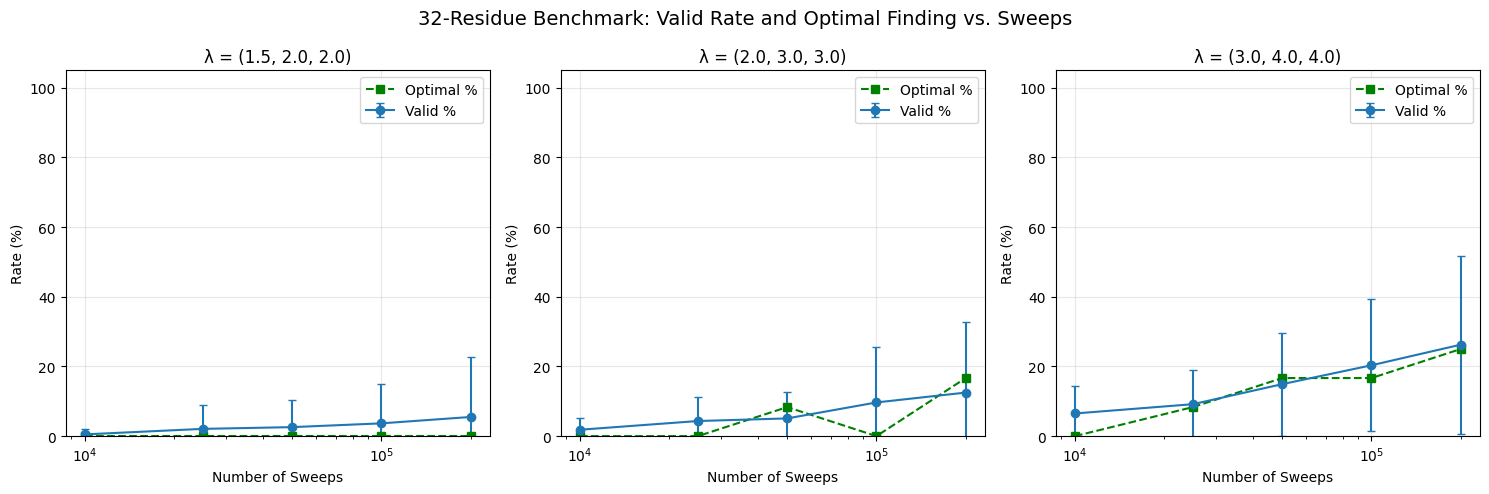

In [ ]:
# Plot 1: Performance by lambda
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, lam in zip(axes, LAMBDA_CONFIGS):
    sweeps_list = sorted(set(k[0] for k in config_summary.keys()))
    valid_rates = [config_summary[(s, lam)]['avg_valid'] for s in sweeps_list]
    valid_stds = [config_summary[(s, lam)]['std_valid'] for s in sweeps_list]
    optimal_rates = [config_summary[(s, lam)]['pct_optimal'] for s in sweeps_list]

    ax.errorbar(sweeps_list, valid_rates, yerr=valid_stds, fmt='o-', label='Valid %', capsize=3)
    ax.plot(sweeps_list, optimal_rates, 's--', label='Optimal %', color='green')

    ax.set_xlabel('Number of Sweeps')
    ax.set_ylabel('Rate (%)')
    ax.set_title(f'λ = {lam}')
    ax.set_xscale('log')
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('32-Residue Benchmark: Valid Rate and Optimal Finding vs. Sweeps', fontsize=14)
plt.tight_layout()
plt.show()

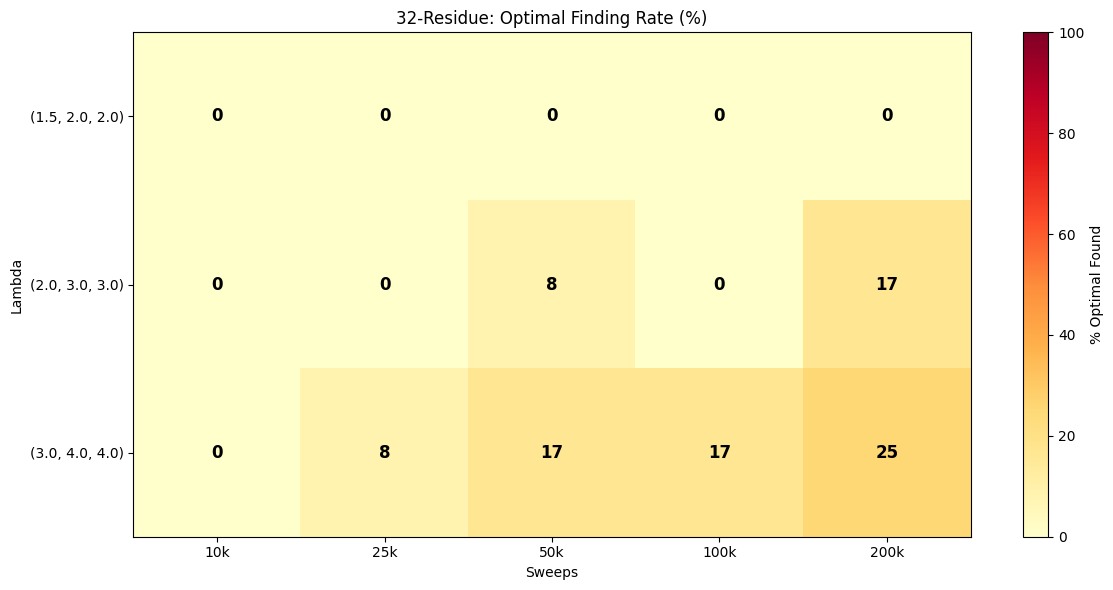

In [ ]:
# Plot 2: Heatmap
fig, ax = plt.subplots(figsize=(12, 6))

sweeps_list = sorted(set(k[0] for k in config_summary.keys()))
matrix = np.array([[config_summary[(s, lam)]['pct_optimal'] for s in sweeps_list] for lam in LAMBDA_CONFIGS])

im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(sweeps_list)))
ax.set_xticklabels([f"{s//1000}k" for s in sweeps_list])
ax.set_yticks(range(len(LAMBDA_CONFIGS)))
ax.set_yticklabels([str(l) for l in LAMBDA_CONFIGS])
ax.set_xlabel('Sweeps')
ax.set_ylabel('Lambda')
ax.set_title('32-Residue: Optimal Finding Rate (%)')

for i in range(len(LAMBDA_CONFIGS)):
    for j in range(len(sweeps_list)):
        color = 'white' if matrix[i, j] > 50 else 'black'
        ax.text(j, i, f"{matrix[i, j]:.0f}", ha='center', va='center', color=color, fontsize=12, fontweight='bold')

plt.colorbar(im, label='% Optimal Found')
plt.tight_layout()
plt.show()

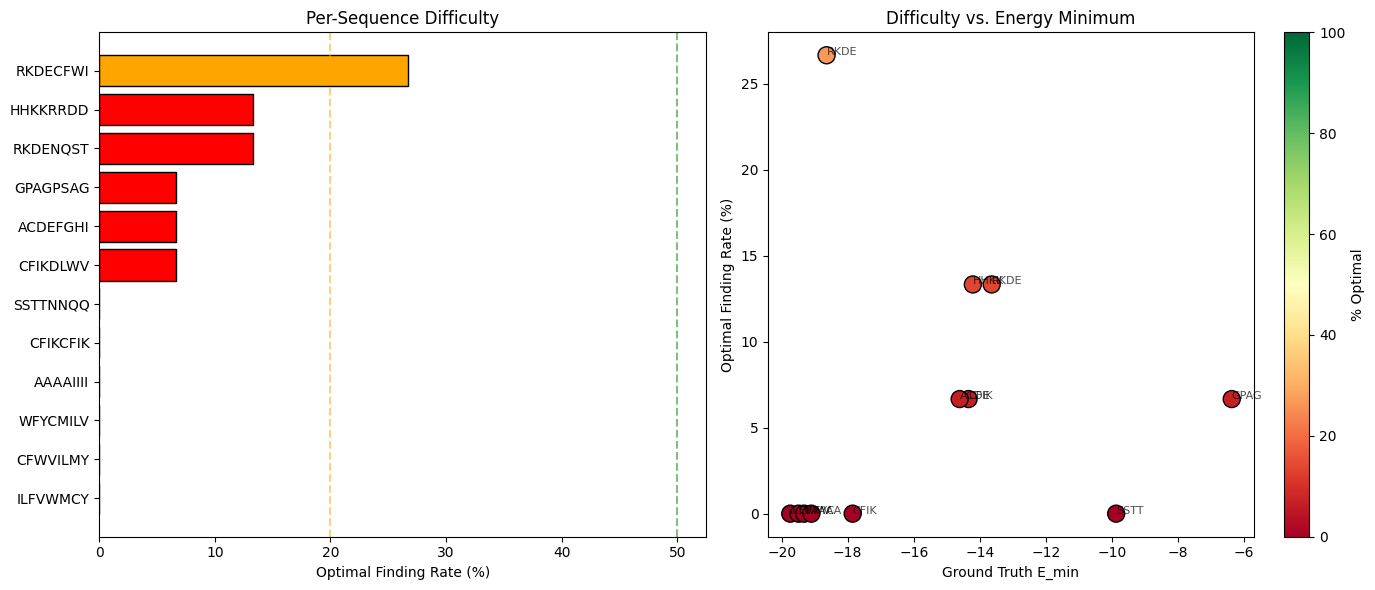

In [ ]:
# Plot 3: Sequence difficulty
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
ax = axes[0]
sequences_short = [s['sequence'][:8] for s in seq_difficulty]
pct_optimal = [s['pct_optimal'] for s in seq_difficulty]
colors = ['green' if p > 50 else 'orange' if p > 20 else 'red' for p in pct_optimal]

bars = ax.barh(range(len(sequences_short)), pct_optimal, color=colors, edgecolor='black')
ax.set_yticks(range(len(sequences_short)))
ax.set_yticklabels(sequences_short)
ax.set_xlabel('Optimal Finding Rate (%)')
ax.set_title('Per-Sequence Difficulty')
ax.axvline(x=50, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5)

# E_min vs difficulty
ax = axes[1]
e_mins = [s['E_min'] for s in seq_difficulty]
scatter = ax.scatter(e_mins, pct_optimal, c=pct_optimal, cmap='RdYlGn', s=150, edgecolor='black', vmin=0, vmax=100)
ax.set_xlabel('Ground Truth E_min')
ax.set_ylabel('Optimal Finding Rate (%)')
ax.set_title('Difficulty vs. Energy Minimum')
plt.colorbar(scatter, ax=ax, label='% Optimal')

for i, s in enumerate(seq_difficulty):
    ax.annotate(s['sequence'][:4], (e_mins[i], pct_optimal[i]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

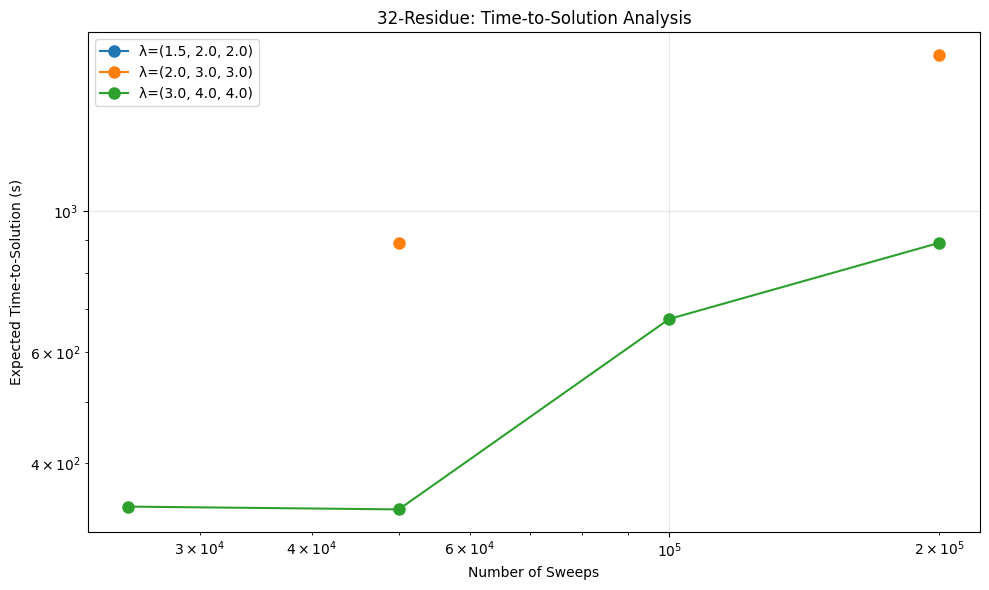

In [ ]:
# Plot 4: Time-to-solution
fig, ax = plt.subplots(figsize=(10, 6))

for lam in LAMBDA_CONFIGS:
    sweeps_list = sorted(set(k[0] for k in config_summary.keys()))
    tts_values = []

    for s in sweeps_list:
        stats = config_summary[(s, lam)]
        p_opt = stats['pct_optimal'] / 100
        if p_opt > 0.01:  # At least 1%
            tts = stats['avg_time'] / p_opt
        else:
            tts = np.nan
        tts_values.append(tts)

    ax.plot(sweeps_list, tts_values, 'o-', label=f'λ={lam}', markersize=8)

ax.set_xlabel('Number of Sweeps')
ax.set_ylabel('Expected Time-to-Solution (s)')
ax.set_title('32-Residue: Time-to-Solution Analysis')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Summary

In [ ]:
print("="*70)
print("32-RESIDUE BENCHMARK SUMMARY")
print("="*70)

print(f"\nProblem Configuration:")
print(f"  Lattice: {LATTICE_ROWS}×{LATTICE_COLS}")
print(f"  Variables: {NUM_VARIABLES}")
print(f"  Instances: {len(SEQUENCES)}")
print(f"  Experiments: {len(all_results)}")
print(f"  Runtime: {total_time/60:.1f} minutes")

print(f"\nGround Truth:")
print(f"  E_min range: [{min(gt['E_min'] for gt in ground_truths.values()):.2f}, {max(gt['E_min'] for gt in ground_truths.values()):.2f}]")

print(f"\nBest Configuration:")
print(f"  Sweeps: {best_key[0]:,}")
print(f"  Lambda: {best_key[1]}")
print(f"  Valid rate: {best['avg_valid']:.1f}% ± {best['std_valid']:.1f}%")
print(f"  Optimal found: {best['pct_optimal']:.1f}%")

print(f"\nKey Findings:")
hardest = seq_difficulty[0]
easiest = seq_difficulty[-1]
print(f"  Hardest: {hardest['sequence'][:16]}... ({hardest['pct_optimal']:.1f}% optimal)")
print(f"  Easiest: {easiest['sequence'][:16]}... ({easiest['pct_optimal']:.1f}% optimal)")

# Find minimum sweeps for decent performance
for sweeps in sorted(set(k[0] for k in config_summary.keys())):
    for lam in LAMBDA_CONFIGS:
        if config_summary[(sweeps, lam)]['pct_optimal'] >= 20:
            print(f"  First config with ≥20% optimal: {sweeps:,} sweeps, λ={lam}")
            break
    else:
        continue
    break

32-RESIDUE BENCHMARK SUMMARY

Problem Configuration:
  Lattice: 8×4
  Variables: 1024
  Instances: 12
  Experiments: 180
  Runtime: 363.8 minutes

Ground Truth:
  E_min range: [-19.74, -6.37]

Best Configuration:
  Sweeps: 200,000
  Lambda: (3.0, 4.0, 4.0)
  Valid rate: 26.2% ± 25.5%
  Optimal found: 25.0%

Key Findings:
  Hardest: ILFVWMCYILFVWMCY... (0.0% optimal)
  Easiest: RKDECFWIRKDECFWI... (26.7% optimal)
  First config with ≥20% optimal: 200,000 sweeps, λ=(3.0, 4.0, 4.0)


In [ ]:
# Save results
results_export = {
    'problem_config': {
        'lattice': f"{LATTICE_ROWS}x{LATTICE_COLS}",
        'num_residues': NUM_RESIDUES,
        'num_variables': NUM_VARIABLES,
        'num_instances': len(SEQUENCES),
        'timestamp': datetime.now().isoformat(),
    },
    'ground_truths': {seq: gt['E_min'] for seq, gt in ground_truths.items()},
    'config_summary': {f"{k[0]}_{k[1]}": v for k, v in config_summary.items()},
    'sequence_difficulty': seq_difficulty,
    'best_config': {'sweeps': best_key[0], 'lambdas': best_key[1], 'stats': best},
    'total_runtime_minutes': total_time / 60,
}

# Uncomment to save:
# with open('results_32res_8x4.json', 'w') as f:
#     json.dump(results_export, f, indent=2, default=str)
# print("Results saved to results_32res_8x4.json")

print("\n✓ Benchmark complete!")


✓ Benchmark complete!
